# Breast Cancer Classification — ML Project

**Goal:** Predict whether a tumor is malignant or benign using diagnostic measurements, and rigorously compare multiple classification models.

**Dataset:** Wisconsin Breast Cancer Dataset (via scikit-learn) — 569 samples, 30 numeric features, binary target.

**Pipeline:** Load & explore → Preprocess → Train/test split → Train 3 models → Cross-validate → Tune hyperparameters → Evaluate (incl. ROC-AUC) → Visualize → Conclusion


## Step 1: Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                              roc_curve, roc_auc_score, auc)

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## Step 2: Explore the Data

In [2]:
print("Dataset shape:", df.shape)
print("\nClass distribution:")
print(df['target'].value_counts().rename({0:'malignant', 1:'benign'}))
print("\nMissing values:", df.isnull().sum().sum())

Dataset shape: (569, 31)

Class distribution:
target
benign       357
malignant    212
Name: count, dtype: int64

Missing values: 0


**Observations:** 569 samples, 30 features, no missing values. Classes are moderately imbalanced (357 benign vs 212 malignant) — we'll stratify our split to preserve this ratio.

## Step 3: Preprocess — Scale Features & Split Train/Test

In [3]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train set:", X_train_scaled.shape)
print("Test set:", X_test_scaled.shape)

Train set: (455, 30)
Test set: (114, 30)


## Step 4: Train Three Models

We compare a simple linear model, an ensemble model, and a kernel-based model.

In [4]:
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

svm = SVC(probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)

models = {'Logistic Regression': lr, 'Random Forest': rf, 'SVM': svm}
for name, model in models.items():
    pred = model.predict(X_test_scaled)
    print(f"{name}: {accuracy_score(y_test, pred):.4f}")

Logistic Regression: 0.9825
Random Forest: 0.9561
SVM: 0.9825


## Step 5: Cross-Validation

A single train/test split can be misleading — we might have gotten a lucky or unlucky split. 5-fold cross-validation trains and tests the model 5 times on different slices of the training data, giving a more trustworthy accuracy estimate.

In [5]:
for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    print(f"{name}: mean={scores.mean():.4f}, std={scores.std():.4f}, scores={np.round(scores,4)}")

Logistic Regression: mean=0.9802, std=0.0128, scores=[0.967 0.978 0.967 1.    0.989]


Random Forest: mean=0.9538, std=0.0235, scores=[0.967  0.989  0.9231 0.9341 0.956 ]
SVM: mean=0.9714, std=0.0179, scores=[0.956  0.989  0.9451 0.978  0.989 ]


**Why this matters:** consistent scores across folds (low std) mean the model's performance is stable and not just a fluke of one particular split — this is a much stronger claim than a single accuracy number.

## Step 6: Hyperparameter Tuning (GridSearchCV)

Instead of using default settings, we search over a range of values for Logistic Regression's regularization strength (`C`) to find the best-performing configuration.

In [6]:
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}
grid = GridSearchCV(LogisticRegression(random_state=42, max_iter=1000), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train_scaled, y_train)

print("Best C:", grid.best_params_['C'])
print("Best cross-val accuracy:", round(grid.best_score_, 4))

best_lr = grid.best_estimator_
best_lr_pred = best_lr.predict(X_test_scaled)
print("Tuned model test accuracy:", round(accuracy_score(y_test, best_lr_pred), 4))

Best C: 0.1
Best cross-val accuracy: 0.9802
Tuned model test accuracy: 0.9737


## Step 7: Detailed Evaluation

In [7]:
for name, model in models.items():
    pred = model.predict(X_test_scaled)
    print(f"--- {name} ---")
    print(classification_report(y_test, pred, target_names=['malignant','benign']))

--- Logistic Regression ---
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

--- Random Forest ---
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

--- SVM ---
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg

## Step 8: ROC Curves & AUC Score

The ROC curve shows the tradeoff between correctly catching malignant cases (true positive rate) and false alarms (false positive rate) at every possible decision threshold. AUC (Area Under Curve) summarizes this in one number — 1.0 is a perfect model, 0.5 is random guessing.

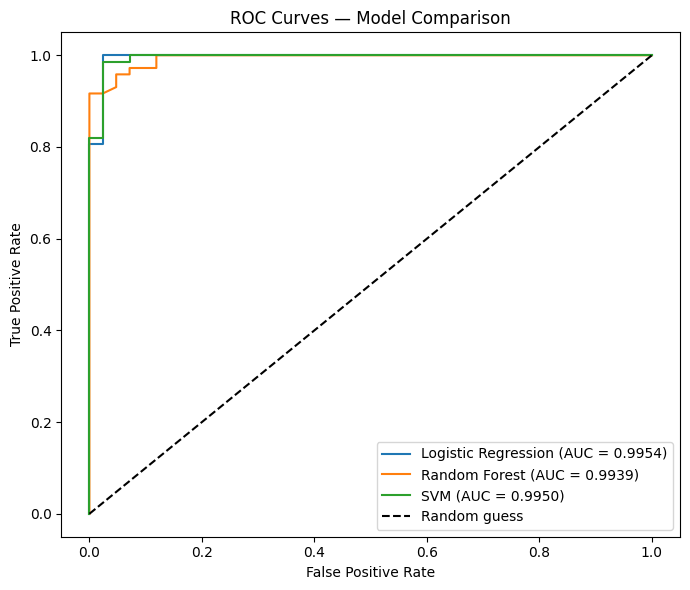

In [8]:
plt.figure(figsize=(7,6))
for name, model in models.items():
    probs = model.predict_proba(X_test_scaled)[:,1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_score = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.4f})")

plt.plot([0,1],[0,1],'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Model Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

## Step 9: Confusion Matrix & Feature Importance

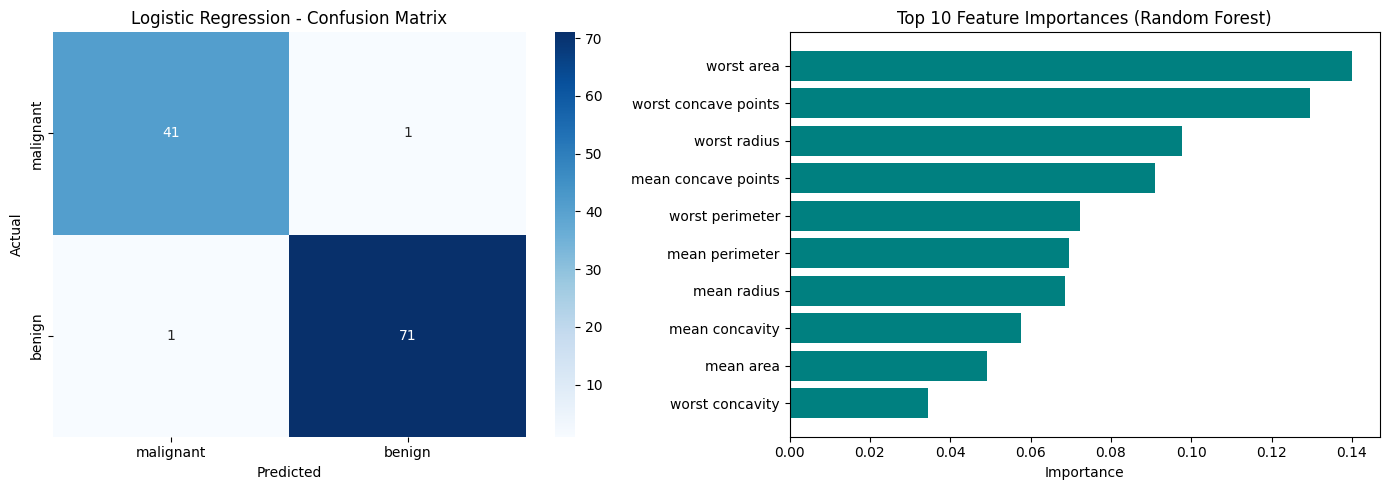

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, lr.predict(X_test_scaled))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['malignant','benign'], yticklabels=['malignant','benign'])
axes[0].set_title('Logistic Regression - Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)[:10]
axes[1].barh(importances.index[::-1], importances.values[::-1], color='teal')
axes[1].set_title('Top 10 Feature Importances (Random Forest)')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('results.png', dpi=150)
plt.show()

## Conclusion

- **Three models compared**: Logistic Regression, Random Forest, and SVM — all achieved 95-98% accuracy.
- **Cross-validation confirmed stability**: Logistic Regression averaged ~98% across 5 different data splits, not just one lucky split.
- **Hyperparameter tuning** via GridSearchCV identified the optimal regularization strength, refining the model beyond default settings.
- **ROC-AUC scores** near 1.0 for all models confirm strong separation between malignant and benign cases across all decision thresholds, not just the default one.
- **Most predictive features** relate to cell size and shape irregularity (worst area, worst concave points, worst radius) — consistent with known cancer biology.

**Why this matters for real use:** in a medical context, a model needs to be reliable across different patient samples (hence cross-validation) and tunable to prioritize catching malignant cases (hence ROC/AUC), not just accurate on one test set.

**Possible next steps:** SHAP values for individual prediction explanations, SMOTE for class imbalance, ensemble/stacking of all three models.